In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd

In [2]:
# JAL1 SEQ3
JAL1_SEQ3_cluster_matrix = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\frame_by_good_cluster_matrix.npy"

# JAL1 SEQ2
JAL1_SEQ2_cluster_matrix = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\frame_by_good_cluster_matrix.npy" 

# -------

# JAl2 SEQ3
JAL2_SEQ3_cluster_matrix =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_3_2023_04_28T08_31_30\processed_data\frame_by_good_cluster_matrix.npy"

# JAL2 SEQ2
JAL2_SEQ2_cluster_matrix =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_seq1_2_2023_04_25T07_32_30\processed_data\frame_by_good_cluster_matrix.npy"

# JAL2 22nd April
jal2_22nd_april = pd.read_csv(r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_2023_04_22T08_38_41\processed_data\spike_count_by_frame_and_goodcluster.csv")
jal2_unique_clusters = len(jal2_22nd_april["spike_clusters"].unique())

# load the cluster matrices
jal2_seq3 = np.load(JAL2_SEQ3_cluster_matrix)
jal1_seq3 = np.load(JAL1_SEQ3_cluster_matrix)
jal1_seq2 = np.load(JAL1_SEQ2_cluster_matrix)
jal2_seq2 = np.load(JAL2_SEQ2_cluster_matrix)


In [3]:
print("JAL2 SEQ3 shape:", jal2_seq3.shape)
print("JAL1 SEQ3 shape:", jal1_seq3.shape)
print("JAL1 SEQ2 shape:", jal1_seq2.shape)
print("JAL2 SEQ2 shape:", jal2_seq2.shape)

JAL2 SEQ3 shape: (332686, 91)
JAL1 SEQ3 shape: (275586, 48)
JAL1 SEQ2 shape: (242566, 48)
JAL2 SEQ2 shape: (343294, 85)


In [4]:
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"

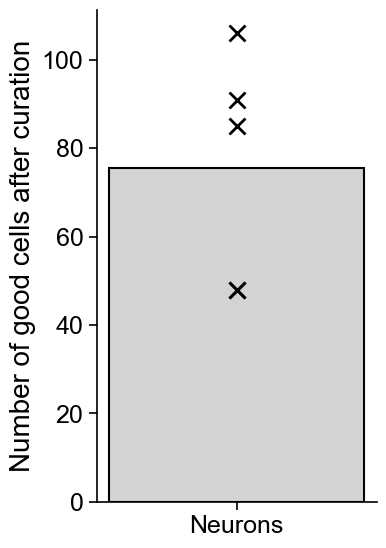

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Number of good cells for each session (last dimension of each matrix)
n_good_cells = [
    jal2_seq3.shape[-1],
    jal1_seq3.shape[-1],
    jal1_seq2.shape[-1],
    jal2_seq2.shape[-1],
    jal2_unique_clusters  # For the 22nd April session
]

# Calculate mean and SEM
mean_cells = np.mean(n_good_cells)
sem_cells = np.std(n_good_cells, ddof=1) / np.sqrt(len(n_good_cells))

plt.rcParams.update({
    "font.size": 18,
    "font.family": "Arial",
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(4, 6))

# Plot the bar (mean)
bar = ax.bar(
    ["Neurons"], [mean_cells],
    color="lightgrey", edgecolor="black", linewidth=1.5, capsize=10, width=0.6
)

# Plot crosses for each session
for val in n_good_cells:
    ax.plot(0, val, marker='x', color='black', markersize=12, markeredgewidth=2)

ax.set_ylabel("Number of good cells after curation")
ax.set_xticks([0])
ax.set_xticklabels(["Neurons"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(width=1.2, length=6)
plt.tight_layout(pad=0.5)
plt.subplots_adjust(left=0.25, right=0.95, bottom=0.13, top=0.95)
plt.show()

#fig.savefig(os.path.join(save_path, "good_neuron_count.eps"), format='eps', bbox_inches='tight', dpi=300)

Number of good cells for the one edge task

No good cell file found or zero cells: Z:/Jasmine_Laurence/Experimental_Data\JAL004\004_mush1_2023_08_22T13_13_41
No good cell file found or zero cells: Z:/Jasmine_Laurence/Experimental_Data\JAL006\JAL006_Habituation_2024_03_01T13_02_08
No good cell file found or zero cells: Z:/Jasmine_Laurence/Experimental_Data\JAL007\JAL007_Habituation_2024_03_01T14_13_42
Summary (excluding JAL001 / JAL002 / JAL003):
   mouse_id                                       session_path  n_good_cells
25   JAL008  Z:/Jasmine_Laurence/Experimental_Data\JAL008\J...            65
26   JAL008  Z:/Jasmine_Laurence/Experimental_Data\JAL008\J...           108
20   JAL007  Z:/Jasmine_Laurence/Experimental_Data\JAL007\J...           111
11   JAL006  Z:/Jasmine_Laurence/Experimental_Data\JAL006\J...           116
12   JAL006  Z:/Jasmine_Laurence/Experimental_Data\JAL006\J...           124
28   JAL008  Z:/Jasmine_Laurence/Experimental_Data\JAL008\J...           140
21   JAL008  Z:/Jasmine_Laurence/Experimental_Data\JAL0

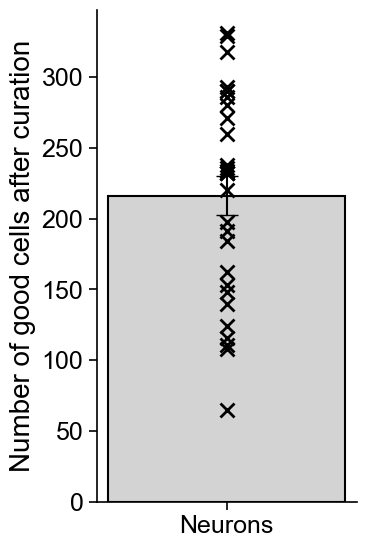

In [7]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
base_path = r"Z:/Jasmine_Laurence/Experimental_Data"
exclude_mice = {"JAL001", "JAL002", "JAL003"}  # exclude JAL1,2,3
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
os.makedirs(save_path, exist_ok=True)

def find_all_sessions(base_path=base_path):
    """Return list of session directories that contain a processed_data folder."""
    session_paths = []
    mouse_dirs = glob.glob(os.path.join(base_path, "JAL*"))
    for mouse_dir in mouse_dirs:
        sessions = glob.glob(os.path.join(mouse_dir, "*"))
        for session in sessions:
            processed_dir = os.path.join(session, "processed_data")
            if os.path.isdir(session) and os.path.isdir(processed_dir):
                session_paths.append(session)
    return session_paths

def get_good_cell_count(session_path):
    """
    Try to load 'frame_by_good_cluster_matrix.npy' or fallback to
    'spike_count_by_frame_and_goodcluster.csv'. Returns count or None.
    """
    processed_dir = os.path.join(session_path, "processed_data")
    npy_path = os.path.join(processed_dir, "frame_by_good_cluster_matrix.npy")
    csv_path = os.path.join(processed_dir, "spike_count_by_frame_and_goodcluster.csv")

    if os.path.exists(npy_path):
        try:
            arr = np.load(npy_path, mmap_mode='r')
            return int(arr.shape[-1])
        except Exception as e:
            print(f"Failed to load npy for {session_path}: {e}")
            return None
    elif os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            if "spike_clusters" in df.columns:
                return int(df["spike_clusters"].nunique())
            # fallback if data is matrix-like in CSV
            return int(df.shape[1])
        except Exception as e:
            print(f"Failed to load csv for {session_path}: {e}")
            return None
    else:
        return None

# Collect counts
all_sessions = find_all_sessions()
records = []

for sess in all_sessions:
    mouse_id = os.path.basename(os.path.dirname(sess))  # e.g. JAL008
    if mouse_id in exclude_mice:
        continue
    n_cells = get_good_cell_count(sess)
    if n_cells is not None and n_cells > 0:
        records.append({"mouse_id": mouse_id, "session_path": sess, "n_good_cells": n_cells})
    else:
        print(f"No good cell file found or zero cells: {sess}")

if not records:
    raise RuntimeError("No sessions collected after exclusions.")

df_counts = pd.DataFrame(records)

# Aggregate (you can choose per-session or per-mouse averages)
# Here we keep per-session values (as in your original plot).
values = df_counts["n_good_cells"].to_numpy()
mean_val = values.mean()
sem_val = values.std(ddof=1) / np.sqrt(len(values))

print("Summary (excluding JAL001 / JAL002 / JAL003):")
print(df_counts.sort_values("n_good_cells"))
print(f"\nMean={mean_val:.2f}, SEM={sem_val:.2f}, N sessions={len(values)}")

# Plot
plt.rcParams.update({
    "font.size": 18,
    "font.family": "Arial",
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

fig, ax = plt.subplots(figsize=(4, 6))
ax.bar(["Neurons"], [mean_val],
       color="lightgrey", edgecolor="black", linewidth=1.5, width=0.6)

# Overlay individual session counts as crosses
for v in values:
    ax.plot(0, v, marker='x', color='black', markersize=10, markeredgewidth=2)

# Add SEM error bar (optional)
ax.errorbar(0, mean_val, yerr=sem_val, fmt='none', ecolor='black', elinewidth=1.5, capsize=8)

ax.set_ylabel("Number of good cells after curation")
ax.set_xticks([0])
ax.set_xticklabels(["Neurons"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(width=1.2, length=6)
plt.tight_layout(pad=0.5)
plt.subplots_adjust(left=0.30, right=0.95, bottom=0.13, top=0.95)
plt.show()


NPX1 session counts (JAL001-003): [ 91.  48.  48.  85. 106.]
NPX1 Mean=75.60 SEM=11.78 N=5
NPX2 session counts (others): [191. 232. 286. 331. 290. 290. 232. 318. 293. 220. 238. 116. 124. 271.
 280. 329. 153. 234. 232. 162. 111. 148. 260. 236. 184.  65. 108. 198.
 140.]
NPX2 Mean=216.28 SEM=13.70 N=29

Levene test: W=3.775 p=0.0609 -> equal_var=True
T-test: t=-4.171 p=2.1589e-04
Cohen's d = -2.020


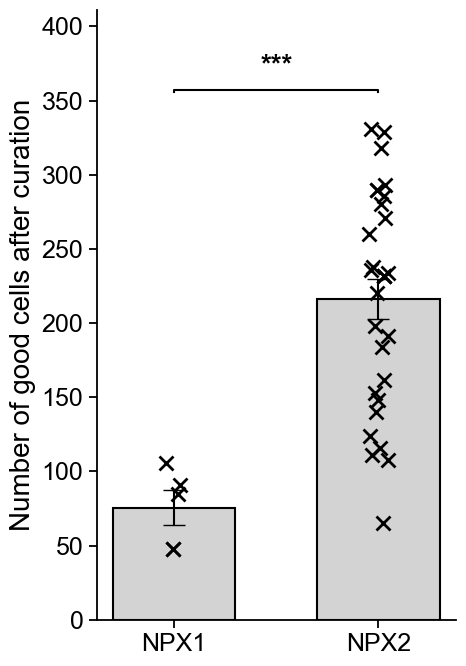

Saved figure: Z:\Laurence\thesis\efizz_chapter\good_neuron_count_NPX1_vs_NPX2.eps

Summary:
NPX1 (n=5): mean=75.60 ± SEM=11.78
NPX2 (n=29): mean=216.28 ± SEM=13.70
T-test p=2.1589e-04 (***) | Cohen's d=-2.020


In [10]:
# Combined NPX1 (JAL001-003) vs NPX2 (all other mice) bar plot with t-test significance

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------------
# 1. Define / verify NPX1 (JAL001-003) session counts already loaded
# ------------------------------------------------------------------
# Assumes you already loaded:
# jal2_seq3, jal1_seq3, jal1_seq2, jal2_seq2, jal2_unique_clusters (22 April)
# If not, load them again here (commented example):
# jal2_seq3 = np.load(JAL2_SEQ3_cluster_matrix)
# jal1_seq3 = np.load(JAL1_SEQ3_cluster_matrix)
# jal1_seq2 = np.load(JAL1_SEQ2_cluster_matrix)
# jal2_seq2 = np.load(JAL2_SEQ2_cluster_matrix)
# jal2_unique_clusters = len(pd.read_csv(<csv>)["spike_clusters"].unique())

n_good_cells_npx1 = np.array([
    jal2_seq3.shape[-1],
    jal1_seq3.shape[-1],
    jal1_seq2.shape[-1],
    jal2_seq2.shape[-1],
    jal2_unique_clusters
], dtype=float)

# ------------------------------------------------------------------
# 2. Gather NPX2 counts (exclude JAL001-003)
# ------------------------------------------------------------------
base_path = r"Z:/Jasmine_Laurence/Experimental_Data"
exclude_mice = {"JAL001", "JAL002", "JAL003"}

def find_all_sessions(base_path=base_path):
    session_paths = []
    for mouse_dir in glob.glob(os.path.join(base_path, "JAL*")):
        for session in glob.glob(os.path.join(mouse_dir, "*")):
            proc = os.path.join(session, "processed_data")
            if os.path.isdir(proc):
                session_paths.append(session)
    return session_paths

def get_good_cell_count(session_path):
    proc = os.path.join(session_path, "processed_data")
    npy_path = os.path.join(proc, "frame_by_good_cluster_matrix.npy")
    csv_path = os.path.join(proc, "spike_count_by_frame_and_goodcluster.csv")
    if os.path.exists(npy_path):
        try:
            arr = np.load(npy_path, mmap_mode='r')
            return int(arr.shape[-1])
        except:
            return None
    if os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            if "spike_clusters" in df.columns:
                return int(df["spike_clusters"].nunique())
            return int(df.shape[1])
        except:
            return None
    return None

records_npx2 = []
for sess in find_all_sessions():
    mouse_id = os.path.basename(os.path.dirname(sess))
    if mouse_id in exclude_mice:
        continue
    n_cells = get_good_cell_count(sess)
    if n_cells is not None and n_cells > 0:
        records_npx2.append(n_cells)

if not records_npx2:
    raise RuntimeError("No NPX2 sessions found.")

n_good_cells_npx2 = np.array(records_npx2, dtype=float)

# ------------------------------------------------------------------
# 3. Descriptives
# ------------------------------------------------------------------
def mean_sem(a):
    return a.mean(), a.std(ddof=1) / np.sqrt(len(a))

mean1, sem1 = mean_sem(n_good_cells_npx1)
mean2, sem2 = mean_sem(n_good_cells_npx2)

print("NPX1 session counts (JAL001-003):", n_good_cells_npx1)
print(f"NPX1 Mean={mean1:.2f} SEM={sem1:.2f} N={len(n_good_cells_npx1)}")
print("NPX2 session counts (others):", n_good_cells_npx2)
print(f"NPX2 Mean={mean2:.2f} SEM={sem2:.2f} N={len(n_good_cells_npx2)}")

# ------------------------------------------------------------------
# 4. Variance check & t-test (independent)
# ------------------------------------------------------------------
lev_stat, lev_p = stats.levene(n_good_cells_npx1, n_good_cells_npx2)
equal_var = lev_p > 0.05
t_stat, p_val = stats.ttest_ind(n_good_cells_npx1, n_good_cells_npx2, equal_var=equal_var)

print(f"\nLevene test: W={lev_stat:.3f} p={lev_p:.4f} -> equal_var={equal_var}")
print(f"T-test: t={t_stat:.3f} p={p_val:.4e}")

# Effect size (Cohen's d)
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    s1, s2 = a.var(ddof=1), b.var(ddof=1)
    sp = np.sqrt(((n1-1)*s1 + (n2-1)*s2)/(n1+n2-2))
    return (a.mean() - b.mean())/sp if sp>0 else np.nan
d_val = cohens_d(n_good_cells_npx1, n_good_cells_npx2)
print(f"Cohen's d = {d_val:.3f}")

# Significance label
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "ns"
star_label = p_to_stars(p_val)

# ------------------------------)------------------------------------
# 5. Plot
# ------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 18,
    "font.family": "Arial",
})

fig, ax = plt.subplots(figsize=(5, 7))

x_pos = [0, 1]
means = [mean1, mean2]
sems  = [sem1, sem2]

bar_colors = ["lightgrey", "lightgrey"]
ax.bar(x_pos, means, yerr=sems, capsize=8,
       color=bar_colors, edgecolor='black', linewidth=1.5, width=0.6)

# Overlay individual points (jitter slightly to see overlaps)
rng = np.random.default_rng(42)
jitter1 = (rng.uniform(-0.05, 0.05, len(n_good_cells_npx1)))
jitter2 = (rng.uniform(-0.05, 0.05, len(n_good_cells_npx2)))
for x_off, arr, jit in zip(x_pos, [n_good_cells_npx1, n_good_cells_npx2], [jitter1, jitter2]):
    for xv, yv in zip(np.full_like(arr, x_off), arr):
        ax.plot(xv + jit[np.where(arr==yv)[0][0]], yv, marker='x', color='black',
                markersize=10, markeredgewidth=2)

ax.set_ylabel("Number of good cells after curation")
ax.set_xticks(x_pos)
ax.set_xticklabels(["NPX1", "NPX2"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.3)
ax.tick_params(width=1.3, length=6)

# Significance annotation
y_max = max(n_good_cells_npx1.max(), n_good_cells_npx2.max())
line_y = y_max * 1.08
ax.plot([x_pos[0], x_pos[0], x_pos[1], x_pos[1]],
        [line_y*0.995, line_y, line_y, line_y*0.995],
        color='black', linewidth=1.5)
ax.text(0.5, line_y*1.02, star_label, ha='center', va='bottom', fontsize=20, fontweight='bold')

ax.set_ylim(0, line_y*1.15)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6. Optional save
# ------------------------------------------------------------------
save_path = r"Z:\Laurence\thesis\efizz_chapter"
os.makedirs(save_path, exist_ok=True)
out_file = os.path.join(save_path, "good_neuron_count_NPX1_vs_NPX2.eps")
fig.savefig(out_file, format='eps', dpi=300, bbox_inches='tight')
print(f"Saved figure: {out_file}")

# 7. Summary print
# ------------------------------------------------------------------
print(f"\nSummary:\nNPX1 (n={len(n_good_cells_npx1)}): mean={mean1:.2f} ± SEM={sem1:.2f}")
print(f"NPX2 (n={len(n_good_cells_npx2)}): mean={mean2:.2f} ± SEM={sem2:.2f}")
print(f"T-test p={p_val:.4e} ({star_label}) | Cohen's d={d_val:.3f}")